# **Milestone** 1

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# 1. LOAD RAW DATA
df = pd.read_csv("azure_demand_raw.csv")

print("Initial shape:", df.shape)
print(df.head())

Initial shape: (5700, 10)
             timestamp        region service_type  usage_units  \
0  2023-03-12 01:14:50       us-west      Storage      8824.65   
1  2023-01-31 10:18:59  Europe-North      Compute     13098.88   
2  2023-08-30 21:38:21       us-east      Storage          NaN   
3  2024-02-19 05:23:30       us east      Storage      6408.14   
4  2024-03-19 21:40:00       us-west      Compute     11940.33   

   provisioned_capacity  cost_usd  availability_pct  cloud_spend_index  \
0                  8000   2823.89             99.94              92.91   
1                 10000   6287.46             99.69             103.90   
2                  8000       NaN             99.57              90.63   
3                  8000   2050.61             99.46             100.01   
4                 10000   5731.36             99.89              96.41   

   enterprise_demand_index  new_service_launch  
0                     1.21                   0  
1                     1.35        

In [ ]:
# 2. FIX TIMESTAMP
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])
df = df.sort_values('timestamp')

In [ ]:
# 3. REMOVE DUPLICATES
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (5500, 10)


In [ ]:
# 4. STANDARDIZE REGION NAMES
df['region'] = (
    df['region']
    .str.strip()
    .str.lower()
    .str.replace(" ", "-", regex=False)
)

df['region'] = df['region'].replace({
    'us-east': 'US-East',
    'us-west': 'US-West',
    'india-south': 'India-South',
    'europe-north': 'Europe-North'
})


In [ ]:
# 5. STANDARDIZE SERVICE TYPE
df['service_type'] = df['service_type'].str.title()

In [ ]:
# 6. HANDLE MISSING VALUES

# Time-series interpolation for usage
df['usage_units'] = df['usage_units'].interpolate(method='linear')

# Cost recompute if missing
df['cost_usd'] = df['cost_usd'].fillna(df['usage_units'] * 0.45)

# Availability forward fill
df['availability_pct'] = df['availability_pct'].ffill()

# Economic variables --> median
df['cloud_spend_index'] = df['cloud_spend_index'].fillna(
    df['cloud_spend_index'].median()
)

df['enterprise_demand_index'] = df['enterprise_demand_index'].fillna(
    df['enterprise_demand_index'].median()
)

# Technical binary variable
df['new_service_launch'] = df['new_service_launch'].fillna(0)


In [ ]:
# 7. VALIDATION RULES

# Remove unrealistic usage
df = df[df['usage_units'] > 0]

# Availability must be realistic
df = df[(df['availability_pct'] >= 95) & (df['availability_pct'] <= 100)]

# Remove negative costs
df = df[df['cost_usd'] > 0]

print("\nRemaining NaNs:\n", df.isnull().sum())
print("Final shape after cleaning:", df.shape)



Remaining NaNs:
 timestamp                  0
region                     0
service_type               0
usage_units                0
provisioned_capacity       0
cost_usd                   0
availability_pct           0
cloud_spend_index          0
enterprise_demand_index    0
new_service_launch         0
dtype: int64
Final shape after cleaning: (5500, 10)


In [ ]:
# 8. SAVE CLEAN DATA
df.to_csv("azure_demand_cleaned.csv", index=False)

print("Clean dataset saved successfully.")


Clean dataset saved successfully.


# **Milestone 2**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("azure_demand_cleaned.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(df.shape)
df.head()

(5500, 10)


,timestamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,cloud_spend_index,enterprise_demand_index,new_service_launch
0,2023-01-01 00:54:15,Europe-North,Compute,11070.03,10000,5313.61,99.60,110.15,1.14,0
1,2023-01-01 03:41:33,India-South,Compute,10606.77,10000,5091.25,99.84,98.46,1.24,0
2,2023-01-01 08:32:08,US-East,Storage,8647.21,8000,2767.11,99.57,108.16,1.07,1
3,2023-01-01 10:45:17,India-South,Compute,14125.23,10000,6780.11,99.91,128.31,1.24,0
4,2023-01-01 12:25:13,US-East,Compute,10985.42,10000,5273.00,99.80,102.13,1.27,0


In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['week_of_year'] = df['timestamp'].dt.isocalendar().week.astype(int)
print(df)

               timestamp        region service_type  usage_units  \
0    2023-01-01 00:54:15  Europe-North      Compute     11070.03   
1    2023-01-01 03:41:33   India-South      Compute     10606.77   
2    2023-01-01 08:32:08       US-East      Storage      8647.21   
3    2023-01-01 10:45:17   India-South      Compute     14125.23   
4    2023-01-01 12:25:13       US-East      Compute     10985.42   
...                  ...           ...          ...          ...   
5495 2024-03-30 12:42:31       US-East      Compute      9205.24   
5496 2024-03-30 14:43:55   India-South      Storage     13582.78   
5497 2024-03-30 18:25:09   India-South      Compute     14645.86   
5498 2024-03-30 19:54:04       US-West      Storage     12837.44   
5499 2024-03-30 23:57:13       US-West      Compute     12670.51   

      provisioned_capacity   cost_usd  availability_pct  cloud_spend_index  \
0                    10000  5313.6100             99.60             110.15   
1                    10000 

In [ ]:
df['lag_1_usage'] = df['usage_units'].shift(1)
df['lag_7_usage'] = df['usage_units'].shift(7)
df['lag_14_usage'] = df['usage_units'].shift(14)
print(df)

               timestamp        region service_type  usage_units  \
0    2023-01-01 00:54:15  Europe-North      Compute     11070.03   
1    2023-01-01 03:41:33   India-South      Compute     10606.77   
2    2023-01-01 08:32:08       US-East      Storage      8647.21   
3    2023-01-01 10:45:17   India-South      Compute     14125.23   
4    2023-01-01 12:25:13       US-East      Compute     10985.42   
...                  ...           ...          ...          ...   
5495 2024-03-30 12:42:31       US-East      Compute      9205.24   
5496 2024-03-30 14:43:55   India-South      Storage     13582.78   
5497 2024-03-30 18:25:09   India-South      Compute     14645.86   
5498 2024-03-30 19:54:04       US-West      Storage     12837.44   
5499 2024-03-30 23:57:13       US-West      Compute     12670.51   

      provisioned_capacity   cost_usd  availability_pct  cloud_spend_index  \
0                    10000  5313.6100             99.60             110.15   
1                    10000 

In [ ]:
df['rolling_mean_3'] = df['usage_units'].rolling(window=3).mean()
df['rolling_mean_7'] = df['usage_units'].rolling(window=7).mean()

df['rolling_std_7'] = df['usage_units'].rolling(window=7).std()
print(df)

               timestamp        region service_type  usage_units  \
0    2023-01-01 00:54:15  Europe-North      Compute     11070.03   
1    2023-01-01 03:41:33   India-South      Compute     10606.77   
2    2023-01-01 08:32:08       US-East      Storage      8647.21   
3    2023-01-01 10:45:17   India-South      Compute     14125.23   
4    2023-01-01 12:25:13       US-East      Compute     10985.42   
...                  ...           ...          ...          ...   
5495 2024-03-30 12:42:31       US-East      Compute      9205.24   
5496 2024-03-30 14:43:55   India-South      Storage     13582.78   
5497 2024-03-30 18:25:09   India-South      Compute     14645.86   
5498 2024-03-30 19:54:04       US-West      Storage     12837.44   
5499 2024-03-30 23:57:13       US-West      Compute     12670.51   

      provisioned_capacity   cost_usd  availability_pct  cloud_spend_index  \
0                    10000  5313.6100             99.60             110.15   
1                    10000 

In [ ]:
threshold = df['usage_units'].mean() + df['usage_units'].std()
df['demand_spike'] = (df['usage_units'] > threshold).astype(int)
print(df)

               timestamp        region service_type  usage_units  \
0    2023-01-01 00:54:15  Europe-North      Compute     11070.03   
1    2023-01-01 03:41:33   India-South      Compute     10606.77   
2    2023-01-01 08:32:08       US-East      Storage      8647.21   
3    2023-01-01 10:45:17   India-South      Compute     14125.23   
4    2023-01-01 12:25:13       US-East      Compute     10985.42   
...                  ...           ...          ...          ...   
5495 2024-03-30 12:42:31       US-East      Compute      9205.24   
5496 2024-03-30 14:43:55   India-South      Storage     13582.78   
5497 2024-03-30 18:25:09   India-South      Compute     14645.86   
5498 2024-03-30 19:54:04       US-West      Storage     12837.44   
5499 2024-03-30 23:57:13       US-West      Compute     12670.51   

      provisioned_capacity   cost_usd  availability_pct  cloud_spend_index  \
0                    10000  5313.6100             99.60             110.15   
1                    10000 

In [ ]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [ ]:
df['service_type'] = df['service_type'].map({
    'Compute': 1,
    'Storage': 0
})

In [ ]:
df = df.dropna().reset_index(drop=True)
print("After lag/rolling cleanup:", df.shape)

After lag/rolling cleanup: (5486, 24)


In [ ]:
features = [
    'usage_units',
    'provisioned_capacity',
    'cost_usd',
    'availability_pct',
    'cloud_spend_index',
    'enterprise_demand_index',
    'new_service_launch',
    'hour', 'day', 'day_of_week', 'month', 'week_of_year',
    'lag_1_usage', 'lag_7_usage', 'lag_14_usage',
    'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7',
    'demand_spike'
]

target = 'usage_units'

In [ ]:
df.to_csv("azure_demand_feature_engineered.csv", index=False)
print("Milestone-2 dataset saved successfully")

Milestone-2 dataset saved successfully


# **Milestone 3**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("azure_demand_feature_engineered.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,cloud_spend_index,enterprise_demand_index,new_service_launch,hour,...,lag_1_usage,lag_7_usage,lag_14_usage,rolling_mean_3,rolling_mean_7,rolling_std_7,demand_spike,region_India-South,region_US-East,region_US-West
0,2023-01-02 05:19:30,1,7269.32,10000,3489.27,99.60,104.03,0.88,0,5,...,7571.60,6568.69,11070.03,7996.660000,9110.874286,2496.418998,0,False,False,True
1,2023-01-02 06:22:43,0,10429.23,8000,3337.35,99.95,125.06,1.24,0,6,...,7269.32,8632.58,10606.77,8423.383333,9367.538571,2531.165982,0,False,False,False
2,2023-01-02 07:51:21,1,10260.58,10000,4925.08,99.63,104.13,1.03,1,7,...,10429.23,7188.33,8647.21,9319.710000,9806.431429,2350.212465,0,False,False,True
3,2023-01-02 09:35:47,1,6776.61,10000,3252.77,99.53,91.35,0.83,0,9,...,10260.58,9614.94,14125.23,9155.473333,9400.955714,2618.309468,0,False,False,False
4,2023-01-02 10:57:45,0,11442.92,8000,3661.74,99.85,129.24,1.05,0,10,...,6776.61,14350.29,10985.42,9493.370000,8985.617143,1807.366048,0,False,True,False


In [3]:
target = "usage_units"

features = df.drop(columns=["timestamp","usage_units"]).columns

X = df[features]
y = df[target]

In [4]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [5]:
rf = RandomForestRegressor(random_state=42)

rf_params = {

"n_estimators":[200,300,400,500],

"max_depth":[10,15,20,None],

"min_samples_split":[2,5,10],

"min_samples_leaf":[1,2,4]

}

rf_search = RandomizedSearchCV(

rf,
rf_params,
n_iter=15,
cv=3,
scoring="neg_mean_absolute_error",
n_jobs=-1,
random_state=42

)

rf_search.fit(X_train,y_train)

best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict(X_test)

print("Best RF Parameters:",rf_search.best_params_)

Best RF Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 15}


In [6]:
xgb = XGBRegressor(random_state=42)

xgb_params = {

"n_estimators":[300,400,500,600],

"max_depth":[4,6,8],

"learning_rate":[0.01,0.03,0.05,0.1],

"subsample":[0.7,0.8,0.9,1],

"colsample_bytree":[0.7,0.8,0.9,1]

}

xgb_search = RandomizedSearchCV(

xgb,
xgb_params,
n_iter=15,
cv=3,
scoring="neg_mean_absolute_error",
n_jobs=-1,
random_state=42

)

xgb_search.fit(X_train,y_train)

best_xgb = xgb_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)

print("Best XGB Parameters:",xgb_search.best_params_)

Best XGB Parameters: {'subsample': 1, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 1}


In [7]:
def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    bias = np.mean(y_pred-y_true)

    return mae,rmse,bias

In [8]:
rf_mae,rf_rmse,rf_bias = evaluate(y_test,rf_pred)
xgb_mae,xgb_rmse,xgb_bias = evaluate(y_test,xgb_pred)

In [9]:
results = pd.DataFrame({

"Model":["Random Forest","XGBoost"],

"MAE":[rf_mae,xgb_mae],

"RMSE":[rf_rmse,xgb_rmse],

"Forecast Bias":[rf_bias,xgb_bias]

})

results.sort_values("RMSE")

,Model,MAE,RMSE,Forecast Bias
0,Random Forest,182.283003,464.448815,7.964612
1,XGBoost,236.318070,542.598074,1.159007


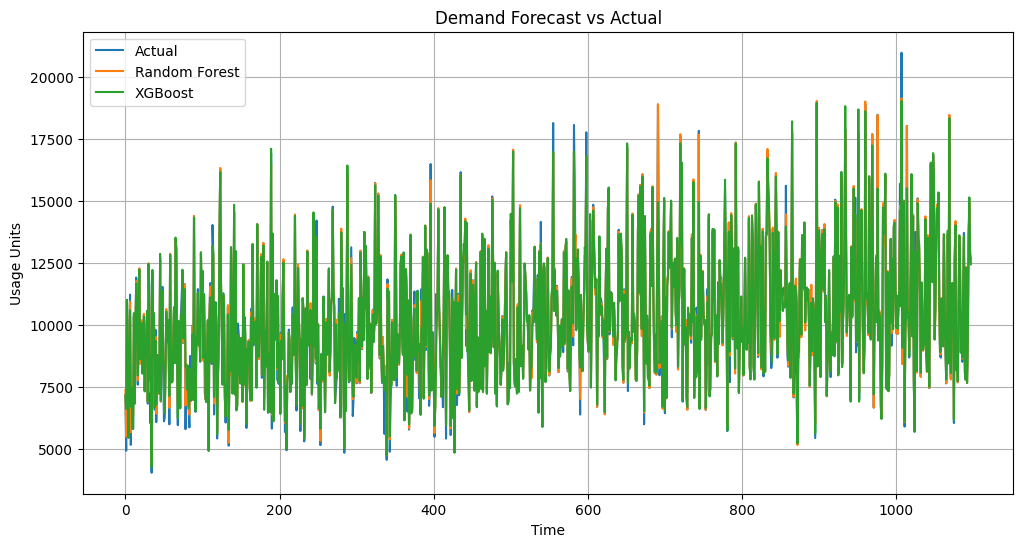

In [10]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,label="Actual")

plt.plot(rf_pred,label="Random Forest")

plt.plot(xgb_pred,label="XGBoost")

plt.title("Demand Forecast vs Actual")

plt.xlabel("Time")

plt.ylabel("Usage Units")

plt.legend()

plt.grid(True)

plt.show()

In [11]:
best_model = results.sort_values("RMSE").iloc[0]["Model"]
print("Best Model:",best_model)

Best Model: Random Forest
